In [1]:
import numpy as np
import numpy.testing as npt
from scipy import stats
from scipy.stats import t,ttest_ind
from scipy.stats import f
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.regression._prediction import get_prediction
from statsmodels.stats.outliers_influence import OLSInfluence,MLEInfluence
from statsmodels.graphics.gofplots import qqplot_2samples,ProbPlot,qqplot
import pandas as pd
from patsy import dmatrices
from numpy.testing import assert_almost_equal, assert_allclose
import matplotlib.pyplot as plt
import seaborn as sns

# some_file.py
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,getRegressionEqn


In [2]:
path  = r"C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\Notes\mlx\stat_analysis\Ch-5-TRANSFORMATIONS_AND_WEIGHTING_TO_CORRECT\DataSet\wls_data_set-1.txt"
df = pd.read_csv(path)
print(df.columns)


Index(['id', 'num_res', 'cost'], dtype='object')


In [3]:
y, X = dmatrices(
                 formula_like = 'cost ~ num_res', 
                 data=df,
                 return_type='dataframe'
                 )
res = sm.OLS(y, X).fit()
Eqn = getRegressionEqn(res)

=============================== Regression eqn =============================================
19.473  + 3.269 num_res 


In [4]:
err_Var = np.var(res.resid)
weights = 1/err_Var 
res_wls = sm.WLS(y, X, weights= weights).fit()
print(res_wls.summary())

                            WLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.889
Model:                            WLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     80.19
Date:                Sun, 05 Oct 2025   Prob (F-statistic):           4.33e-06
Time:                        12:37:43   Log-Likelihood:                -34.242
No. Observations:                  12   AIC:                             72.48
Df Residuals:                      10   BIC:                             73.45
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     19.4727      5.516      3.530      0.0

c:\Users\TODO\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=12
  res = hypotest_fun_out(*samples, **kwds)


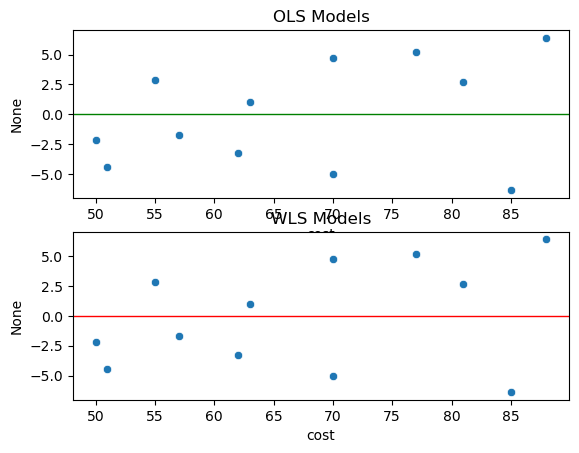

In [5]:
fig = plt.figure()
ax1 = fig.add_subplot(211)
ax1.axhline(linewidth=1, color='g')
ax1.set_title('OLS Models')
sns.scatterplot(x = df['cost'],y =res.resid,ax=ax1)
ax2 = fig.add_subplot(212)
ax2.axhline(linewidth=1, color='r')
ax2.set_title('WLS Models')
sns.scatterplot(x = df['cost'],y =res_wls.resid,ax=ax2)

plt.show()

TODO

Require more research on WLS